## EDA And Feature Engineering Of Google Play Store Dataset

1) Problem statement.
Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose, with 2.56 million available through the Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our Objective is to find the Most Popular Category, find the App with largest number of installs , the App with largest size etc.
2) Data Collection.

The data consists of 20 column and 10841 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Observation:** Dataset loaded; first look at columns and sample rows.

**Conclusion:** Proceed to check shape, info and summary statistics.

In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### Handling Missing Values
**Observation:** Some columns (e.g., `Rating`) have missing values; a few columns have very small counts of missing rows.
**Conclusion:** Impute `Rating` with median and drop rows with missing `Type`, `Content Rating`, `Current Ver`, `Android Ver`.

In [6]:
print("Missing values before handling:")
display(df.isnull().sum())

Missing values before handling:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [7]:
# Impute 'Rating' with its median
median_rating = df['Rating'].median()
df['Rating'].fillna(median_rating, inplace=True)

# Drop rows where 'Type', 'Current Ver', or 'Android Ver' are missing
df.dropna(subset=['Type','Content Rating', 'Current Ver', 'Android Ver'], inplace=True)

print("\nMissing values after handling:")
display(df.isnull().sum())


Missing values after handling:


,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


**Observation:** After imputation and dropping a few rows, missingness is resolved for key columns.
**Conclusion:** Continue with datatype conversions and cleaning.

In [8]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


### Converting the Datatype of Reviews from object into integer
**Observation:** `Reviews` currently stored as object strings; converting to integer allows numeric analysis.

In [9]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [10]:
# convert reviews to int using a working copy
df_copy=df.copy()
df_copy['Reviews']=df_copy['Reviews'].astype(int)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10829 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10829 non-null  object 
 1   Category        10829 non-null  object 
 2   Rating          10829 non-null  float64
 3   Reviews         10829 non-null  int64  
 4   Size            10829 non-null  object 
 5   Installs        10829 non-null  object 
 6   Type            10829 non-null  object 
 7   Price           10829 non-null  object 
 8   Content Rating  10829 non-null  object 
 9   Genres          10829 non-null  object 
 10  Last Updated    10829 non-null  object 
 11  Current Ver     10829 non-null  object 
 12  Android Ver     10829 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.4+ MB


**Observation:** `Reviews` converted to integer on `df_copy` and basic info updated.
**Conclusion:** Proceed to clean `Size`, `Installs`, and `Price`.

In [11]:
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '5.5M', '17M', '39M', '31M',
       '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M', '5.2M',
       '11M', '24M', 'Varies with device', '9.4M', '15M', '10M', '1.2M',
       '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k', '3.6M',
       '5.7M', '8.6M', '2.4M', '27M', '2.7M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

### Feature Transformation
#### Converting numeric columns which are object datatype into integer and float
**Observation:** `Size` contains 'M','k' and 'Varies with device'.


In [12]:
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size']=df_copy['Size'].astype(float)

# Impute missing 'Size' values (originally 'Varies with device') with the mode
mode_size = df_copy['Size'].mode()[0]
df_copy['Size'].fillna(mode_size, inplace=True)

In [13]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10829 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10829 non-null  object 
 1   Category        10829 non-null  object 
 2   Rating          10829 non-null  float64
 3   Reviews         10829 non-null  int64  
 4   Size            10829 non-null  float64
 5   Installs        10829 non-null  object 
 6   Type            10829 non-null  object 
 7   Price           10829 non-null  object 
 8   Content Rating  10829 non-null  object 
 9   Genres          10829 non-null  object 
 10  Last Updated    10829 non-null  object 
 11  Current Ver     10829 non-null  object 
 12  Android Ver     10829 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.4+ MB


In [14]:
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+'], dtype=object)

In [15]:
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [16]:
chars_to_remove=['+',',','$']
cols_to_clean=['Installs','Price']
for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [17]:
df_copy['Price'].unique()
df_copy['Installs'].unique()
df_copy['Installs']=df_copy['Installs'].astype('int')
df_copy['Price']=df_copy['Price'].astype('float')
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10829 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10829 non-null  object 
 1   Category        10829 non-null  object 
 2   Rating          10829 non-null  float64
 3   Reviews         10829 non-null  int64  
 4   Size            10829 non-null  float64
 5   Installs        10829 non-null  int64  
 6   Type            10829 non-null  object 
 7   Price           10829 non-null  float64
 8   Content Rating  10829 non-null  object 
 9   Genres          10829 non-null  object 
 10  Last Updated    10829 non-null  object 
 11  Current Ver     10829 non-null  object 
 12  Android Ver     10829 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.4+ MB


**Observation:** `Installs` and `Price` cleaned to numeric types; `Size` standardized.
**Conclusion:** Extract temporal features and remove duplicates before analysis.

In [18]:
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10829 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10829 non-null  object        
 1   Category        10829 non-null  object        
 2   Rating          10829 non-null  float64       
 3   Reviews         10829 non-null  int64         
 4   Size            10829 non-null  float64       
 5   Installs        10829 non-null  int64         
 6   Type            10829 non-null  object        
 7   Price           10829 non-null  float64       
 8   Content Rating  10829 non-null  object        
 9   Genres          10829 non-null  object        
 10  Last Updated    10829 non-null  datetime64[ns]
 11  Current Ver     10829 non-null  object        
 12  Android Ver     10829 non-null  object        
 13  Day             10829 non-null  int32         
 14  Month           10829 non-null  int32         
 15  Year   

In [19]:
df_copy['Content Rating'].value_counts()
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [20]:
df_copy[df_copy.duplicated('App')].shape

(1181, 16)

In [21]:
df_copy=df_copy.drop_duplicates(subset=['App'],keep='first')
df_copy[df_copy.duplicated('App')].shape

(0, 16)

**Observation:** Duplicates removed; temporal and content-rating features available.
**Conclusion:** Ready for feature-type separation and visualization.

In [22]:
## Lets go ahead and explore more data
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']

We have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


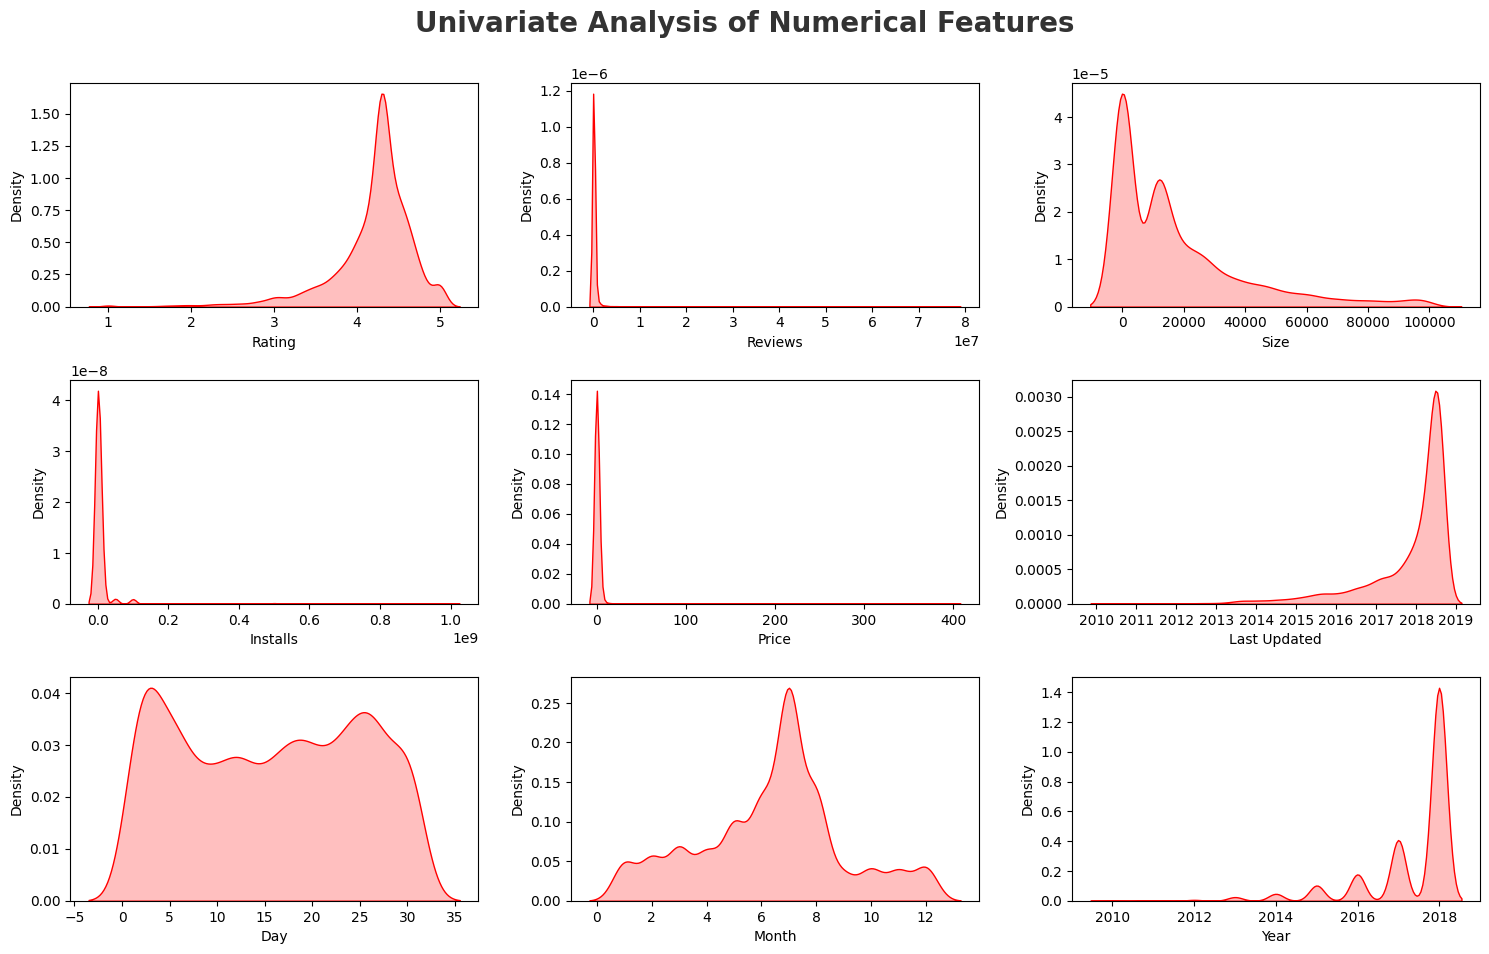

In [23]:
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

### Skewness and Kurtosis Analysis
**Observation:** The skewness and kurtosis calculation identifies which numeric features are more concentrated and which have long tails.

**What kurtosis means:** Kurtosis describes how heavy the tails of a distribution are compared with a normal distribution. Higher kurtosis means more extreme values and heavier tails, while lower kurtosis means fewer extreme values and lighter tails.

**Conclusion:** These metrics help decide whether transformations such as log scaling are appropriate for downstream analysis.

In [29]:
display(df_copy['Last Updated'].head()) # Last updated is the column which says when was the app last upaded in the dataset

,Last Updated
0,2018-01-07
1,2018-01-15
2,2018-08-01
3,2018-06-08
4,2018-06-20


In [30]:
from scipy.stats import skew, kurtosis

# Filter out 'Last Updated' from numeric_features for skewness and kurtosis calculation
features_for_stats = [feature for feature in numeric_features if feature != 'Last Updated']

# Calculate skewness and kurtosis for numeric features
skewness_kurtosis = pd.DataFrame({
    'Feature': features_for_stats,
    'Skewness': [skew(df_copy[feature]) for feature in features_for_stats],
    'Kurtosis': [kurtosis(df_copy[feature]) for feature in features_for_stats]
})

print("Skewness and Kurtosis Analysis:")
print(skewness_kurtosis.to_string())
print("\nInterpretation:")
print("Skewness > 0.5: Right-skewed | Skewness < -0.5: Left-skewed | -0.5 to 0.5: Approximately symmetric")
print("Kurtosis > 3: Heavy tails | Kurtosis < 3: Light tails | Around 3: Normal-like")

Skewness and Kurtosis Analysis:
    Feature   Skewness    Kurtosis
0    Rating  -1.982449    6.702231
1   Reviews  26.554423  906.129792
2      Size   1.664406    2.553323
3  Installs  15.026669  254.701984
4     Price  22.513958  519.056988
5       Day  -0.008777   -1.320887
6     Month  -0.050176   -0.191293
7      Year  -2.157963    5.026293

Interpretation:
Skewness > 0.5: Right-skewed | Skewness < -0.5: Left-skewed | -0.5 to 0.5: Approximately symmetric
Kurtosis > 3: Heavy tails | Kurtosis < 3: Light tails | Around 3: Normal-like


In summary, features like 'Reviews', 'Installs', and 'Price' are highly right-skewed and have very heavy tails, indicating that a small number of apps account for the vast majority of activity (reviews, installs, and high prices)

Outlier Detection Summary (IQR Method):
        Feature  Outlier Count  Outlier Percentage          Lower Bound          Upper Bound
0        Rating            491            5.089138                 3.25                 5.25
1       Reviews           1655           17.153814           -44111.375            73585.625
2          Size            551            5.711028             -37484.5              62490.7
3      Installs           1978           20.501658           -1497500.0            2498500.0
4         Price            753            7.804726                  0.0                  0.0
5  Last Updated            904            9.369818  2016-03-10 21:00:00  2019-12-13 21:00:00
6           Day              0            0.000000                -18.5                 49.5
7         Month              0            0.000000                  0.5                 12.5
8          Year            801            8.302239               2015.5               2019.5


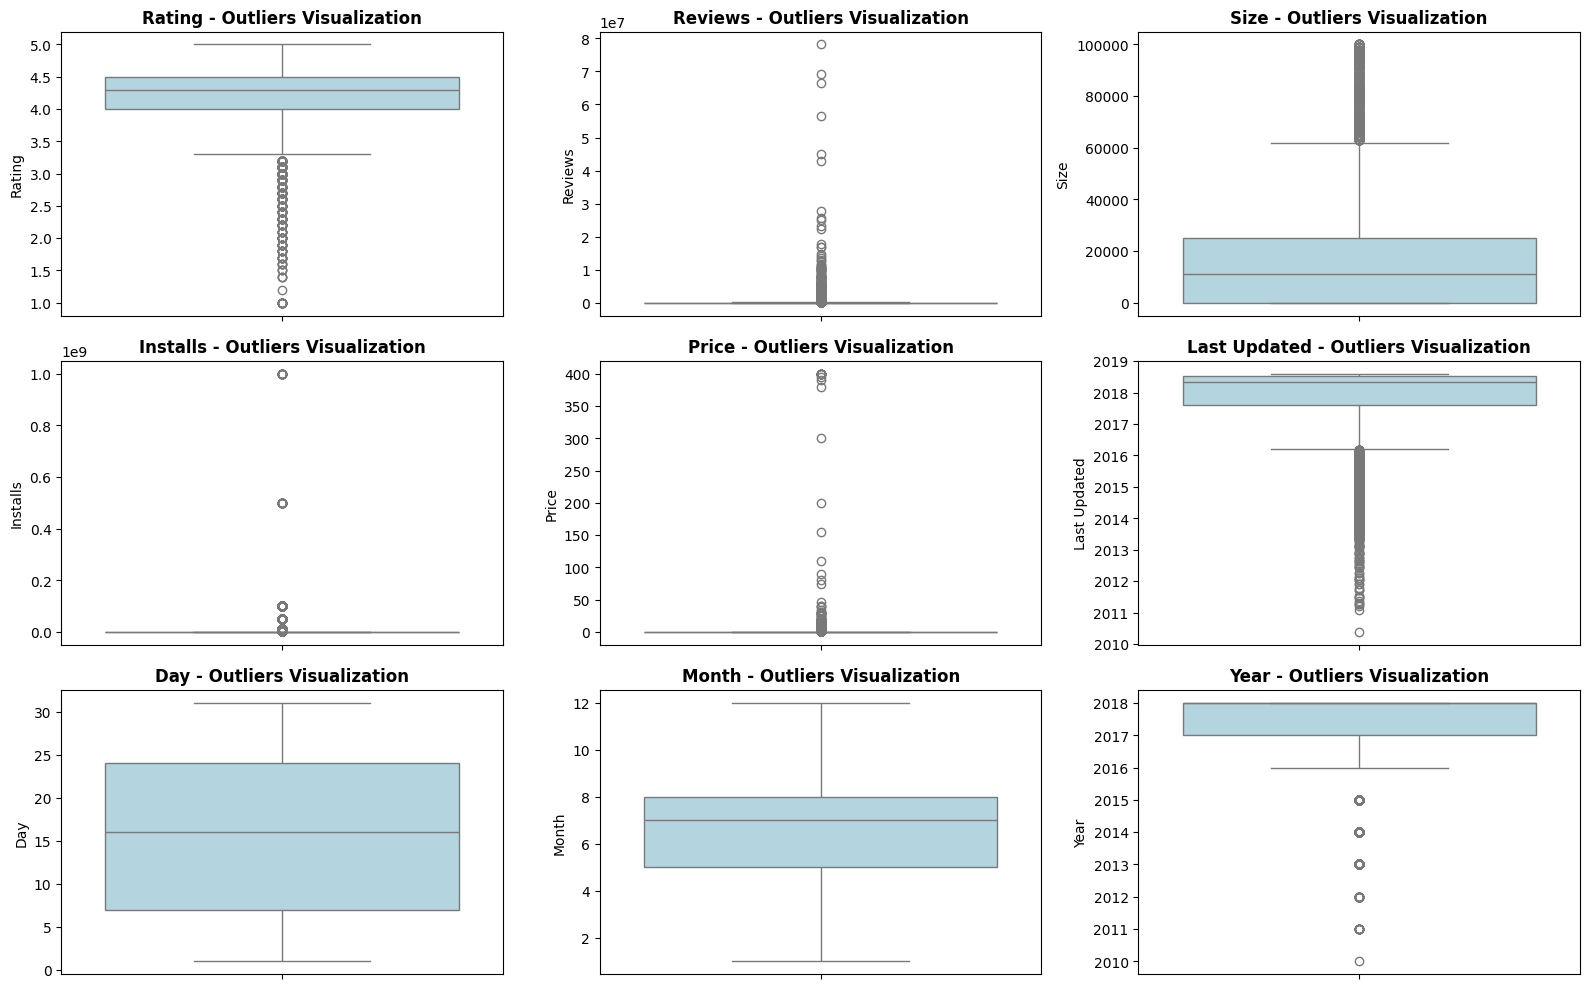

In [34]:
# Outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in numeric features
outlier_summary = []
for feature in numeric_features:
    outliers, lower, upper = detect_outliers_iqr(df_copy, feature)
    outlier_summary.append({
        'Feature': feature,
        'Outlier Count': len(outliers),
        'Outlier Percentage': (len(outliers) / len(df_copy) * 100),
        'Lower Bound': lower,
        'Upper Bound': upper
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Detection Summary (IQR Method):")
print(outlier_df.to_string())

# Visualize outliers with box plots
plt.figure(figsize=(16, 10))
for i in range(len(numeric_features)):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df_copy[numeric_features[i]], color='lightblue')
    plt.title(f'{numeric_features[i]} - Outliers Visualization', fontweight='bold')
    plt.ylabel(numeric_features[i])

plt.tight_layout()
plt.show()

### Outlier Detection and Visualization
**Observation:** Several numeric features contain outliers (expected for skewed distributions).
**Conclusion:** Outliers may be left as-is for analysis or handled case-by-case depending on modelling goals.

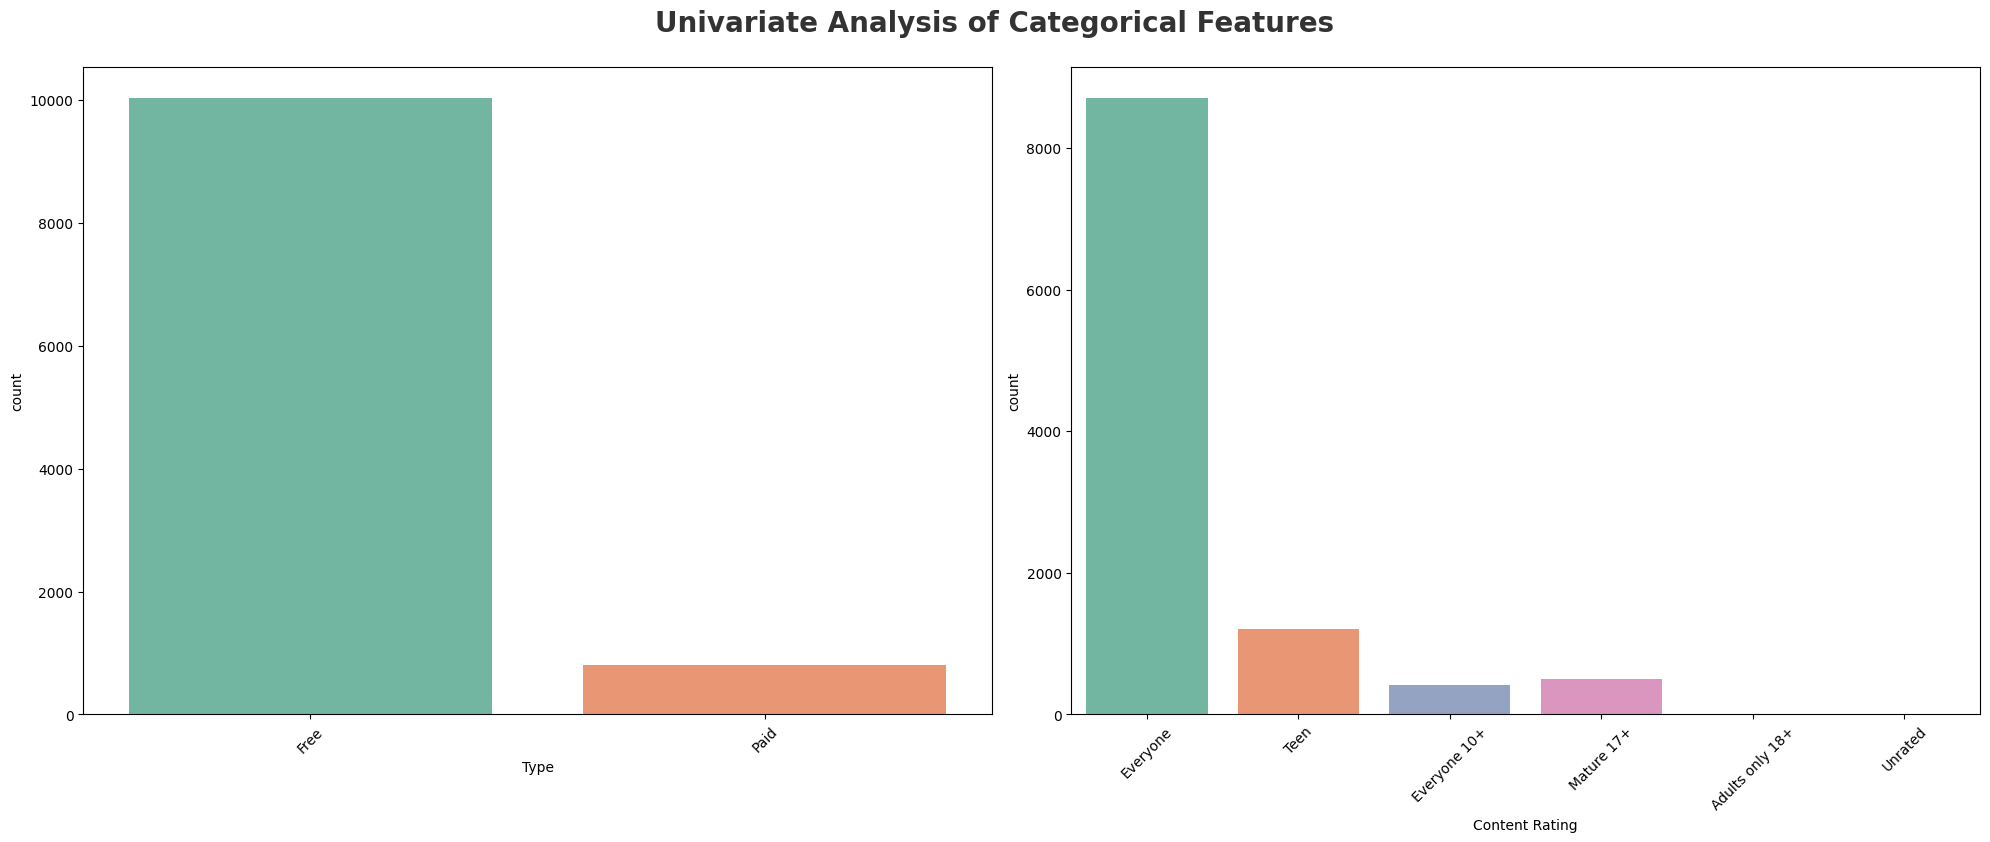

In [35]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

### which is the most popular app category?
**Observation:** Category frequency distribution shows which categories have the most apps.
**Conclusion:** Identify top categories for deeper analysis.

In [36]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


<Axes: ylabel='count'>

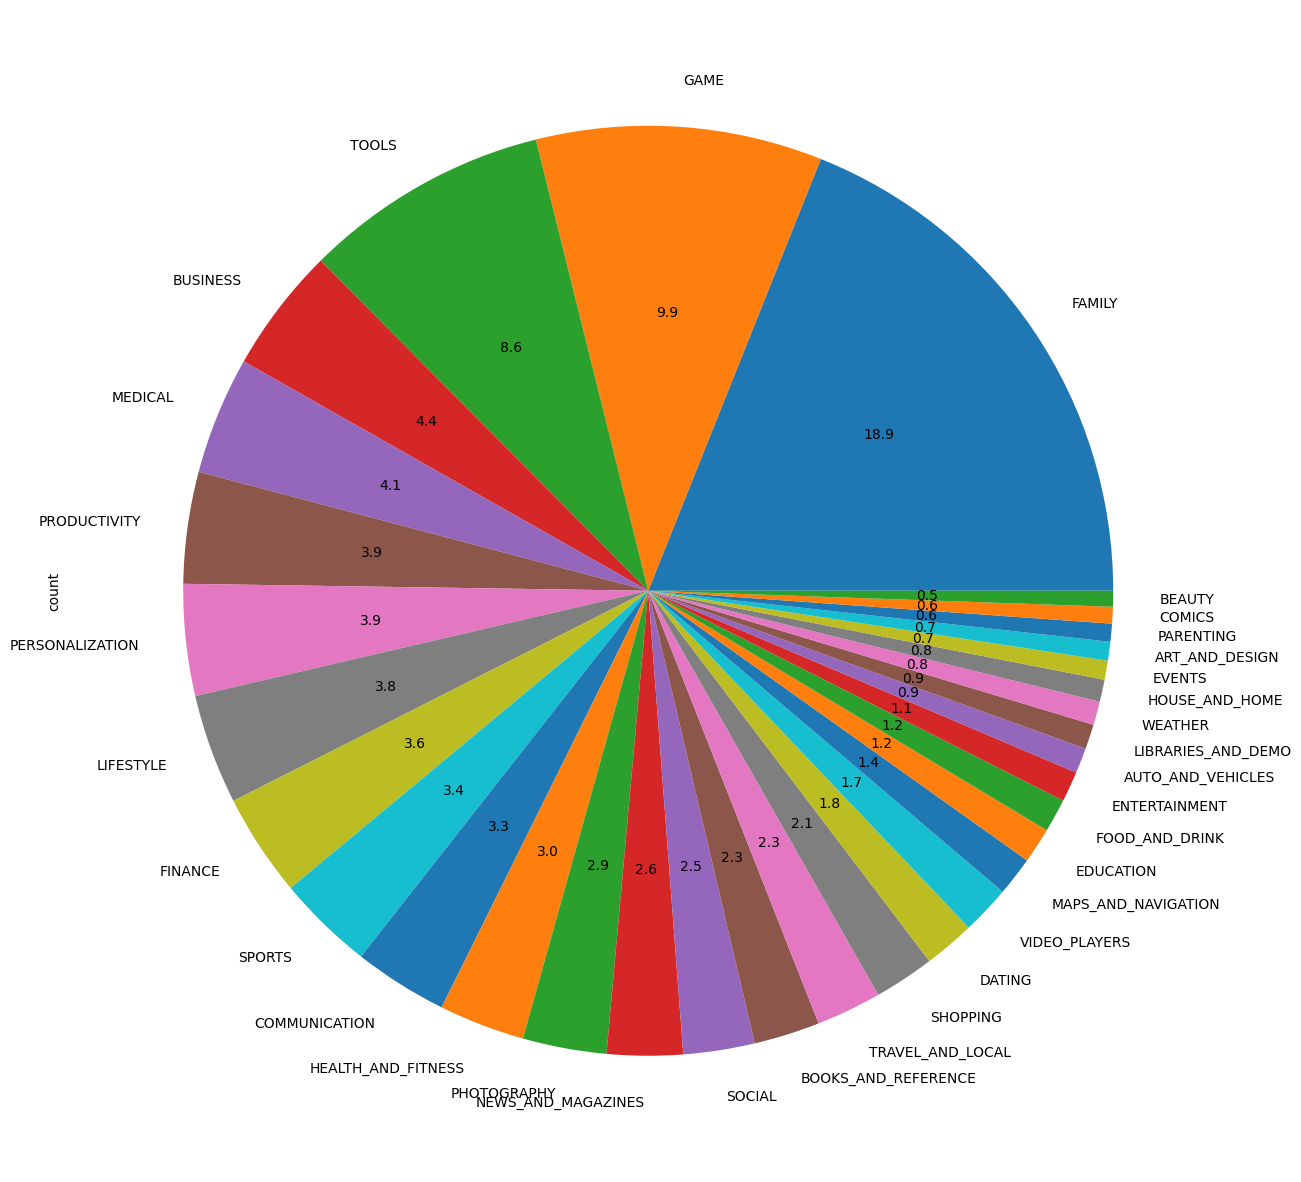

In [37]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],figsize=(15,16),autopct='%1.1f')

### Observations
1. The category distribution is concentrated in a few major segments, while several niche categories have comparatively few apps.
2. The pie chart is useful for seeing relative share, but the exact dominance should be confirmed with the ranked count table and bar chart.

In [38]:
## Top 10 App Categories
category = pd.DataFrame(df_copy['Category'].value_counts())        #Dataframe of apps on the basis of category
category.rename(columns = {'Category':'Count'},inplace=True)

In [39]:
category

,count
Category,
FAMILY,1828
GAME,959
TOOLS,825
BUSINESS,420
MEDICAL,395
PRODUCTIVITY,374
PERSONALIZATION,374
LIFESTYLE,369
FINANCE,345


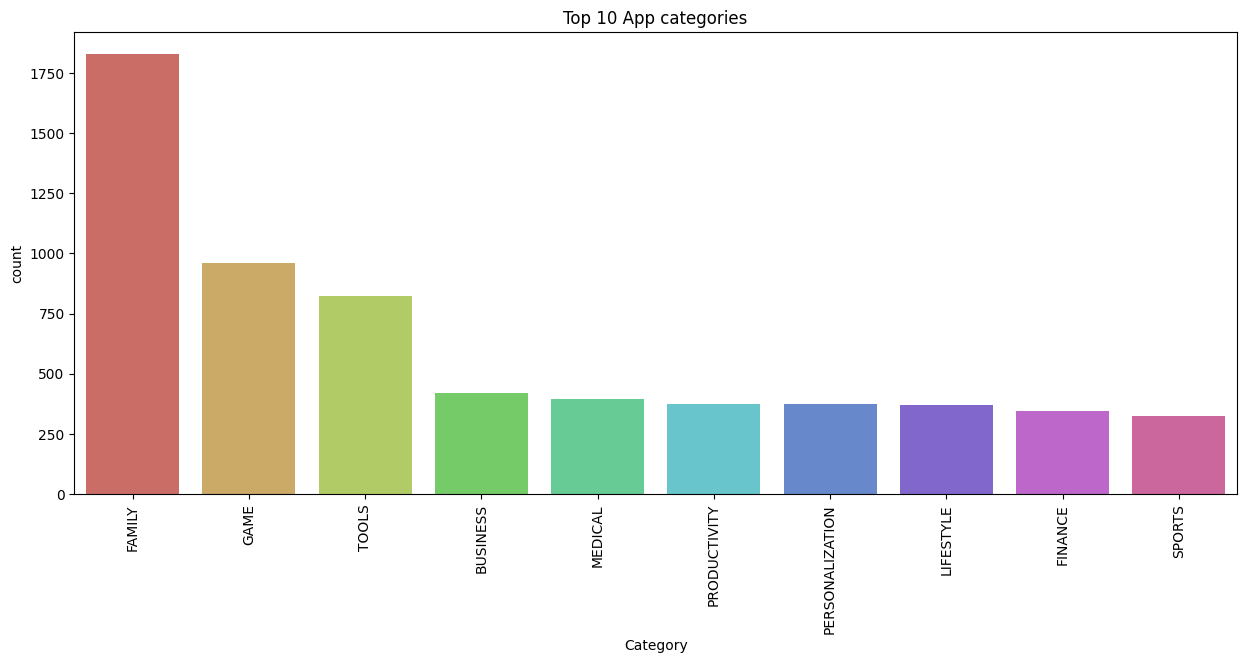

In [40]:
## top 10 app
plt.figure(figsize=(15,6))
sns.barplot(x=category.index[:10], y ='count',data = category[:10],palette='hls')
plt.title('Top 10 App categories')
plt.xticks(rotation=90)
plt.show()

### Insights
1. The highest-volume categories are concentrated in the main consumer and utility segments.
2. Smaller categories contribute far fewer apps, which makes the category distribution clearly imbalanced.

### Which Category has largest number of installations?
**Observation:** Summing installs by category shows which categories generate the most total installs.

Text(0.5, 1.0, 'Most Popular Categories in Play Store')

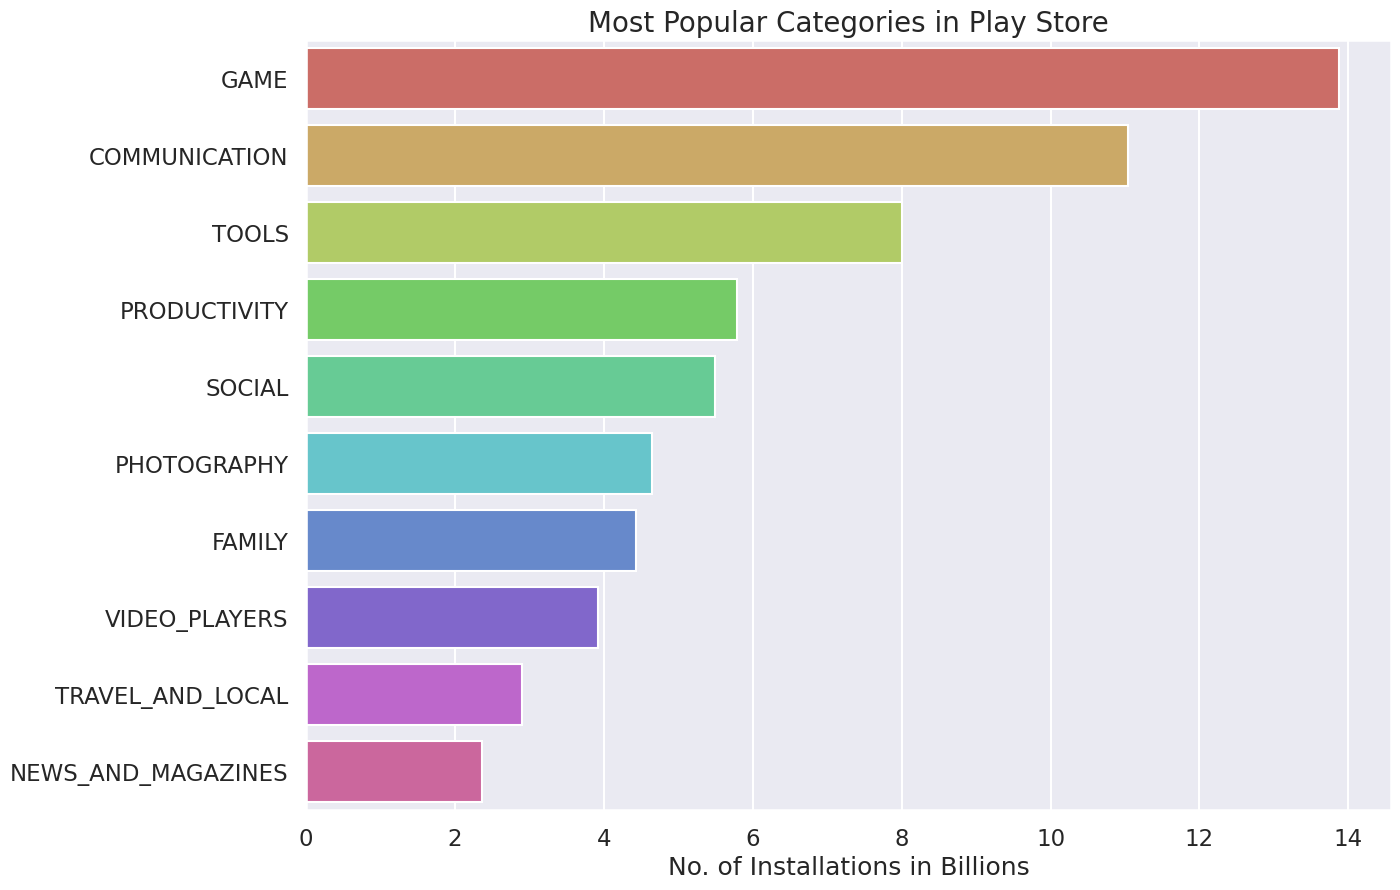

In [41]:
df_cat_installs = df_copy.groupby(['Category'])['Installs'].sum().sort_values(ascending = False).reset_index()
df_cat_installs.Installs = df_cat_installs.Installs/1000000000# converting into billions
df2 = df_cat_installs.head(10)
plt.figure(figsize = (14,10))
sns.set_context("talk")
sns.set_style("darkgrid")
ax = sns.barplot(x = 'Installs' , y = 'Category' , data = df2 ,palette='hls')
ax.set_xlabel('No. of Installations in Billions')
ax.set_ylabel('')
ax.set_title("Most Popular Categories in Play Store", size = 20)

## Bivariate Analysis
#### Correlation Heatmap of Numerical Features
**Observation:** Correlation matrix highlights relationships, e.g., `Reviews` vs `Installs`.
**Conclusion:** High correlation between `Reviews` and `Installs` suggests related user engagement.

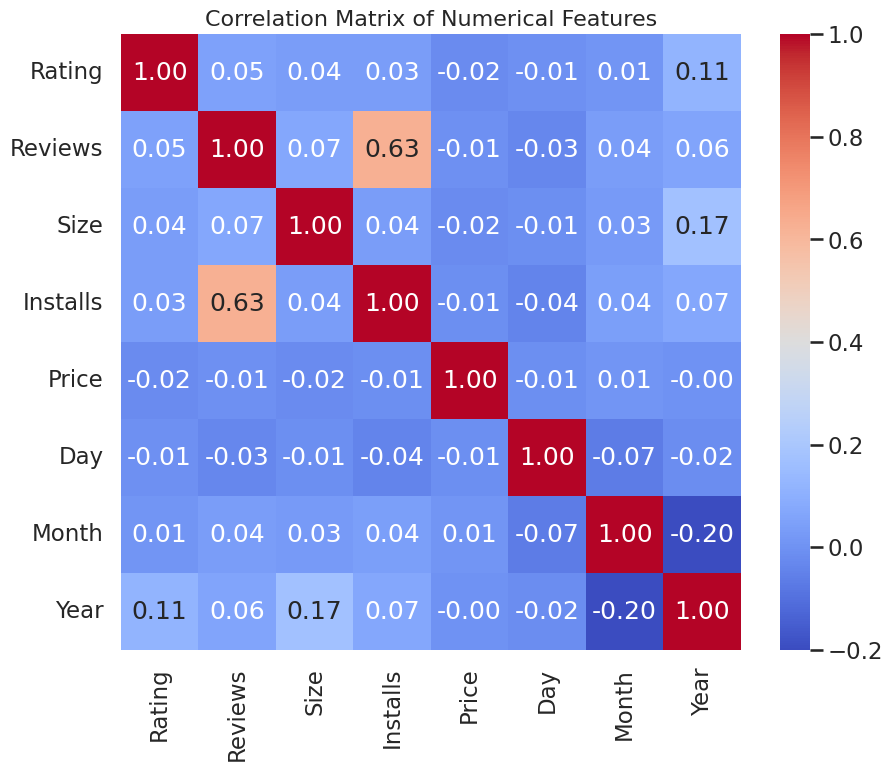

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_copy[['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

#### Rating Distribution by App Type (Free vs. Paid)
**Observation:** Compare rating distributions across app types.

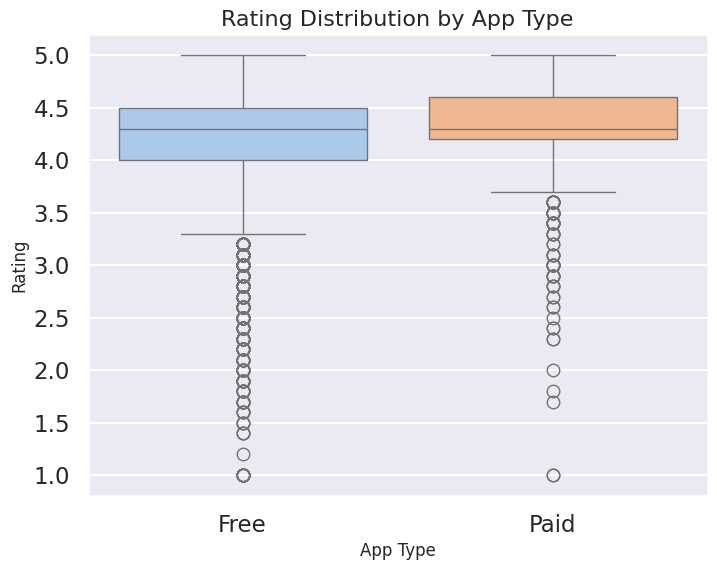

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Rating', data=df_copy, palette='pastel')
plt.title('Rating Distribution by App Type', fontsize=16)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

#### Total Installs by Content Rating
**Observation:** Some content ratings account for more installs than others.

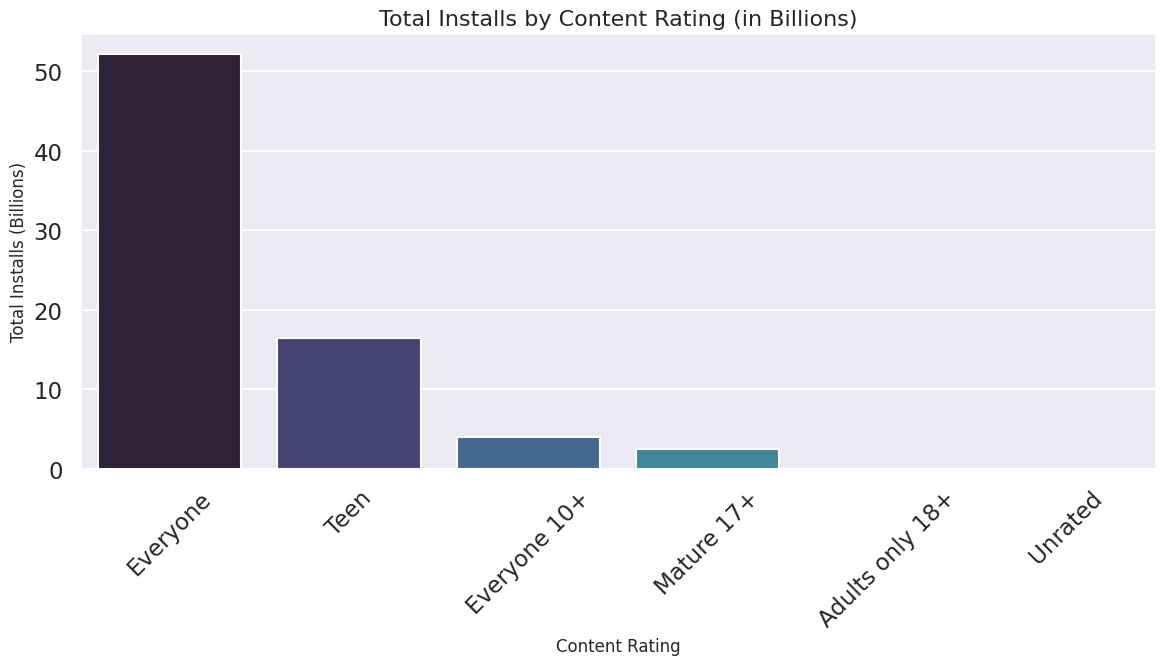

In [44]:
installs_by_content_rating = df_copy.groupby('Content Rating')['Installs'].sum().sort_values(ascending=False).reset_index()
installs_by_content_rating['Installs_Billion'] = installs_by_content_rating['Installs'] / 1_000_000_000 # Convert to billions for better readability

plt.figure(figsize=(12, 7))
sns.barplot(x='Content Rating', y='Installs_Billion', data=installs_by_content_rating, palette='mako')
plt.title('Total Installs by Content Rating (in Billions)', fontsize=16)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Total Installs (Billions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Multivariate Analysis
For multivariate analysis, we will create log-transformed versions of `Reviews` and `Installs` to better handle their skewed distributions and make visualizations more interpretable.

In [45]:
df_copy['log_Reviews'] = np.log1p(df_copy['Reviews'])
df_copy['log_Installs'] = np.log1p(df_copy['Installs'])

#### Installs by Category and Type
**Observation:** Compare log(installs) across top categories split by app `Type`.
**Conclusion:** Free apps typically dominate installs across top categories.

<Figure size 1800x800 with 0 Axes>

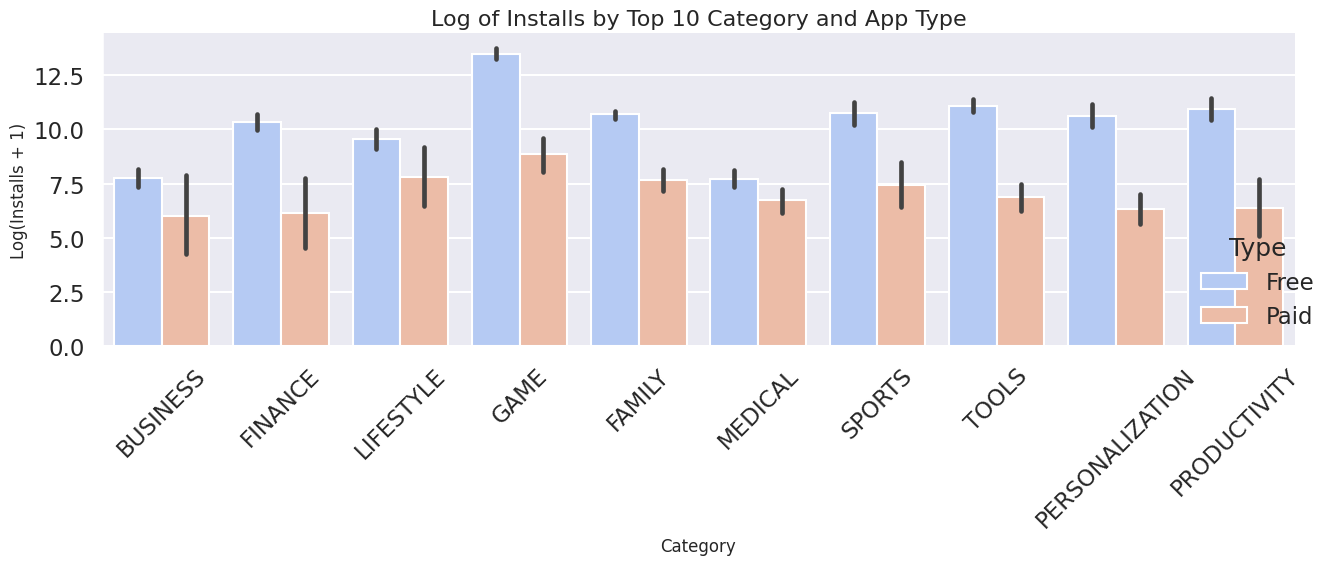

In [46]:
top_categories = df_copy['Category'].value_counts().index[:10]
df_top_categories = df_copy[df_copy['Category'].isin(top_categories)]

plt.figure(figsize=(18, 8))
sns.catplot(x='Category', y='log_Installs', hue='Type', data=df_top_categories, kind='bar', palette='coolwarm', height=6, aspect=2)
plt.title('Log of Installs by Top 10 Category and App Type', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Log(Installs + 1)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Rating Distribution by Content Rating and Type
**Observation:** Inspect rating spread across content ratings and app types.

<Figure size 1500x800 with 0 Axes>

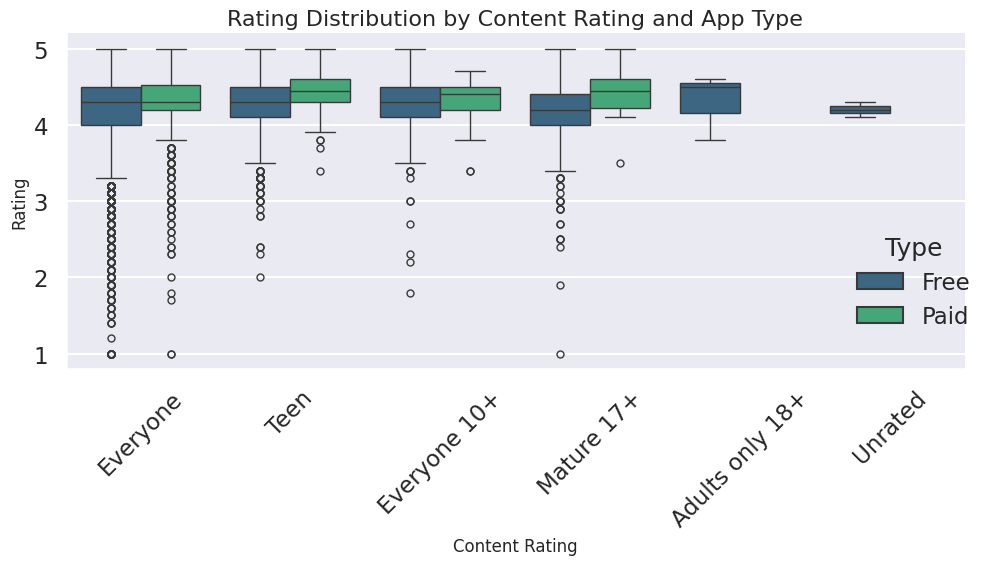

In [47]:
plt.figure(figsize=(15, 8))
sns.catplot(x='Content Rating', y='Rating', hue='Type', data=df_copy, kind='box', palette='viridis', height=6, aspect=1.5)
plt.title('Rating Distribution by Content Rating and App Type', fontsize=16)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusions
The notebook shows a complete EDA workflow: cleaning, type correction, duplicate removal, feature engineering, distribution checks, outlier review, and category-level comparisons. Overall, the Play Store data is highly concentrated in a few major app groups, while installs and reviews move together strongly enough to justify deeper modeling or segment-level strategy analysis. Free apps lead in reach, and content rating is a relevant contextual feature for interpreting app performance.

## Professional Report

### Google Play Store Dataset: Exploratory Data Analysis Summary

**Objective:**
To analyze the Google Play Store dataset, clean and standardize key fields, and identify patterns in app categories, installs, ratings, content rating, and app type.

**Data Preparation:**
The dataset was cleaned by handling missing values, converting `Reviews`, `Size`, `Installs`, and `Price` to usable numeric forms, extracting time-based features from `Last Updated`, and removing duplicate app records.

**Core Concepts Covered:**
- Missing value treatment using median and selective row removal
- Data type conversion and feature engineering
- Univariate analysis of numerical and categorical variables
- Skewness, kurtosis, and outlier assessment
- Category popularity and installation analysis
- Correlation analysis for numeric features
- Bivariate and multivariate comparisons using app type and content rating
- Log transformation for highly skewed variables

**Key Findings:**
- A small number of categories account for a large share of apps and installs.
- `Reviews` and `Installs` are strongly related, which is expected because higher usage typically leads to more user feedback.
- `Reviews`, `Installs`, and `Price` are more skewed than the other numeric variables, so transformation helps interpretation.
- Free apps dominate installation volume across the store.
- Content rating and app type add useful context when comparing ratings and installs.

**Final Conclusion:**
This analysis shows that the Play Store is concentrated around a few high-volume categories, with free apps driving most installs and engagement metrics moving together. From a product and market perspective, the most practical strategy is to focus on high-demand categories, keep the user experience strong enough to support ratings, and use category plus content-rating signals to guide targeting and monetization decisions.